In [16]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)

In [2]:
df_original=pd.read_csv("coffee_shop_ales.csv")   
df = df_original.sample(n=10000, random_state=42)


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 116605 to 19839
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10000 non-null  int64  
 1   transaction_date  10000 non-null  str    
 2   transaction_time  10000 non-null  str    
 3   transaction_qty   10000 non-null  int64  
 4   store_id          10000 non-null  int64  
 5   store_location    10000 non-null  str    
 6   product_id        10000 non-null  int64  
 7   unit_price        10000 non-null  float64
 8   product_category  10000 non-null  str    
 9   product_type      10000 non-null  str    
 10  product_detail    10000 non-null  str    
dtypes: float64(1), int64(4), str(6)
memory usage: 937.5 KB


In [4]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
116605,116867,6/3/23,14:04:38,2,5,Lower Manhattan,38,3.75,Coffee,Barista Espresso,Latte
119259,119521,6/5/23,17:41:39,1,5,Lower Manhattan,79,3.75,Bakery,Scone,Jumbo Savory Scone
105265,105519,5/23/23,16:56:17,3,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
29485,29542,2/21/23,15:40:56,3,5,Lower Manhattan,38,3.75,Coffee,Barista Espresso,Latte
126885,127222,6/12/23,9:23:04,1,8,Hell's Kitchen,36,3.75,Coffee,Premium brewed coffee,Jamaican Coffee River Lg


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler


TARGET_COL = "unit_price"
BATCH_SIZE = 64
EPOCHS = 50
ALPHA=0.001

x = df.drop(columns=[TARGET_COL]) # Features

y = df[TARGET_COL] # Target

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Encoding categorical features using LabelEncoder
def encode_train(df):
    df = df.copy()
    encoders = {}
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].astype(str)
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
            encoders[col] = encoder
    return df, encoders

def encode_test(df, encoders):
    df = df.copy()
    for col, encoder in encoders.items():
        df[col] = df[col].astype(str)
        known = set(encoder.classes_)
        df[col] = df[col].apply(lambda x: encoder.transform([x])[0] if x in known else -1)
    return df

encoded_xtrain, encoders = encode_train(x_train)   # train
encoded_xtest = encode_test(x_test, encoders)  # test


# Pandas to Numpy
x_train = encoded_xtrain.to_numpy()
x_test = encoded_xtest.to_numpy()
y_train_arr = y_train.to_numpy().reshape(-1, 1)
y_test_arr = y_test.to_numpy().reshape(-1, 1)


x_scaler = MinMaxScaler()
scaled_xtrain = x_scaler.fit_transform(encoded_xtrain)
scaled_xtest  = x_scaler.transform(encoded_xtest)

y_scaler = MinMaxScaler()
scaled_ytrain = y_scaler.fit_transform(y_train_arr)
scaled_ytest  = y_scaler.transform(y_test_arr)

# Numpy to Torch Tensor
x_train_tensor = torch.tensor(scaled_xtrain, dtype=torch.float32)
x_test_tensor = torch.tensor(scaled_xtest, dtype=torch.float32)

y_train_tensor = torch.tensor(scaled_ytrain, dtype=torch.float32)
y_test_tensor = torch.tensor(scaled_ytest, dtype=torch.float32)

In [6]:
print("X Train Tensor:", x_train_tensor.shape)
print("Y Train Tensor:", y_train_tensor.shape)
print("X Test Tensor:", x_test_tensor.shape)
print("Y Test Tensor:", y_test_tensor.shape)

X Train Tensor: torch.Size([8000, 10])
Y Train Tensor: torch.Size([8000, 1])
X Test Tensor: torch.Size([2000, 10])
Y Test Tensor: torch.Size([2000, 1])


In [14]:
def make_loaders(x_train, y_train, batch_size):
    train_ds = TensorDataset(x_train, y_train)

    train_size = int(0.9 * len(train_ds))
    val_size = len(train_ds) - train_size

    train_dataset, val_dataset = random_split(
        train_ds,
        [train_size, val_size]
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total_loss = 0

    for bx, by in loader:
        pred = model(bx)
        loss = loss_fn(pred, by)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * bx.size(0)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def val_one_epoch(model, loader, loss_fn):
    model.eval()
    total_val_loss = 0

    for bx, by in loader:
        pred = model(bx)
        loss = loss_fn(pred, by)

        total_val_loss += loss.item() * bx.size(0)

    return total_val_loss / len(loader.dataset)

def fit_model(model, train_loader, val_loader, optimizer, loss_fn, epochs, early_stop_patience=None):

    train_losses, val_losses = [], []
    best_val = float("inf")
    patience_left = early_stop_patience

    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, loss_fn, optimizer)
        val_loss = val_one_epoch(model, val_loader, loss_fn)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)

        if epoch == 1 or epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | train={tr_loss:.4f} | val={val_loss:.4f}")

        # Early stopping
        if early_stop_patience is not None:
            if val_loss < best_val:
                best_val = val_loss
                patience_left = early_stop_patience
            else: 
                patience_left -= 1
                if patience_left <= 0:
                    print(f"Early stop at epoch {epoch} (best val={best_val:.4f})")
                    break

    return train_losses, val_losses


def plot_losses(train_losses, val_losses, title="Loss Curves"):
    plt.figure()
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Val loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


# Bad learning rate

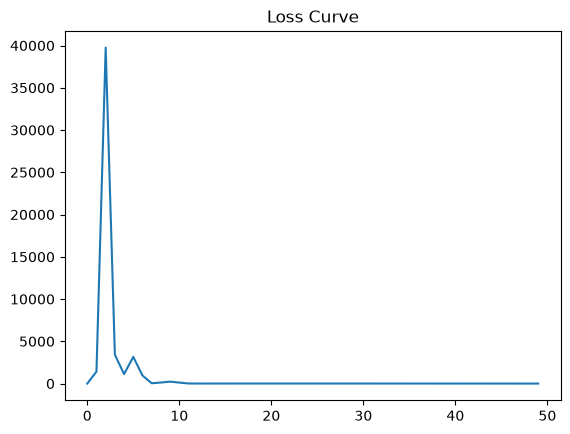

In [8]:
input_dim = x_train_tensor.shape[1] # features
hidden_dim = 64 # hidden units
output_dim = 1 # output units
lr = 1 # Learning rate

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim), #Input
    nn.ReLU(), # Hidden
    nn.Linear(hidden_dim, output_dim)
)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)


losses = []

for epoch in range(50):
    optimizer.zero_grad()
    output = model(x_train_tensor)
    loss = loss_fn(output, y_train_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.plot(losses)
plt.title("Loss Curve")
plt.show()

# Good learning rate

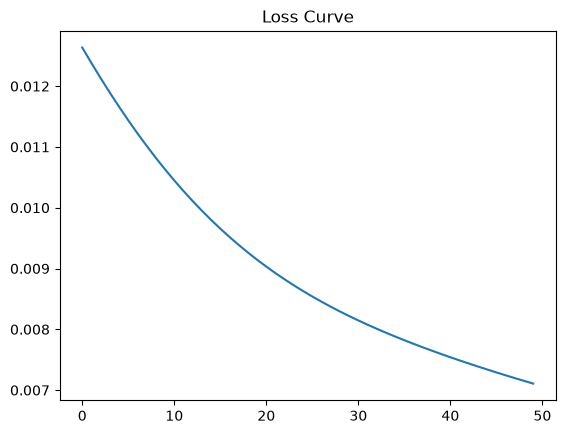

In [12]:
input_dim = x_train_tensor.shape[1] # features
hidden_dim = 64 # hidden units
output_dim = 1 # output units
lr = 0.0001 # Learning rate

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim), #Input
    nn.ReLU(), # Hidden
    nn.Linear(hidden_dim, output_dim)
)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)


losses = []

for epoch in range(50):
    optimizer.zero_grad()
    output = model(x_train_tensor)
    loss = loss_fn(output, y_train_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.plot(losses)
plt.title("Loss Curve")
plt.show()

# Underfitting

Epoch 001 | train=0.2910 | val=0.2602
Epoch 010 | train=0.0435 | val=0.0393
Epoch 020 | train=0.0267 | val=0.0249
Epoch 030 | train=0.0197 | val=0.0179
Epoch 040 | train=0.0133 | val=0.0116
Epoch 050 | train=0.0088 | val=0.0074


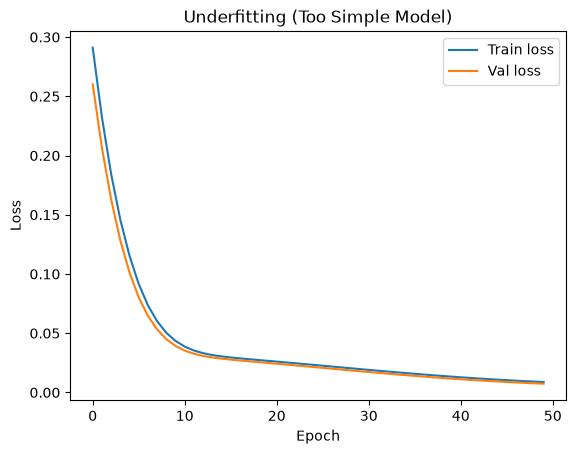

In [27]:
input_dim = x_train_tensor.shape[1] # features
hidden_dim = 1 # hidden units
output_dim = 1 # output units
lr = 0.0001 # Learning rate

train_loader, val_loader = make_loaders(x_train_tensor, y_train_tensor, batch_size=BATCH_SIZE)

small_model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim), #Input
)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(small_model.parameters(), lr=lr)


train_losses, val_losses = fit_model(small_model, train_loader, val_loader, optimizer, loss_fn, epochs=EPOCHS)
plot_losses(train_losses, val_losses, title="Underfitting (Too Simple Model)")


# Overfitting

Epoch 001 | train=0.0042 | val=0.0036
Epoch 010 | train=0.0013 | val=0.0013
Epoch 020 | train=0.0007 | val=0.0008
Epoch 030 | train=0.0004 | val=0.0006
Epoch 040 | train=0.0003 | val=0.0004
Epoch 050 | train=0.0002 | val=0.0003
Epoch 060 | train=0.0001 | val=0.0003
Epoch 070 | train=0.0001 | val=0.0003
Epoch 080 | train=0.0001 | val=0.0003
Epoch 090 | train=0.0001 | val=0.0003
Epoch 100 | train=0.0001 | val=0.0002
Epoch 110 | train=0.0001 | val=0.0002
Epoch 120 | train=0.0001 | val=0.0002
Epoch 130 | train=0.0001 | val=0.0002
Epoch 140 | train=0.0001 | val=0.0002
Epoch 150 | train=0.0000 | val=0.0002
Epoch 160 | train=0.0000 | val=0.0002
Epoch 170 | train=0.0001 | val=0.0002
Epoch 180 | train=0.0000 | val=0.0002
Epoch 190 | train=0.0000 | val=0.0002
Epoch 200 | train=0.0001 | val=0.0002


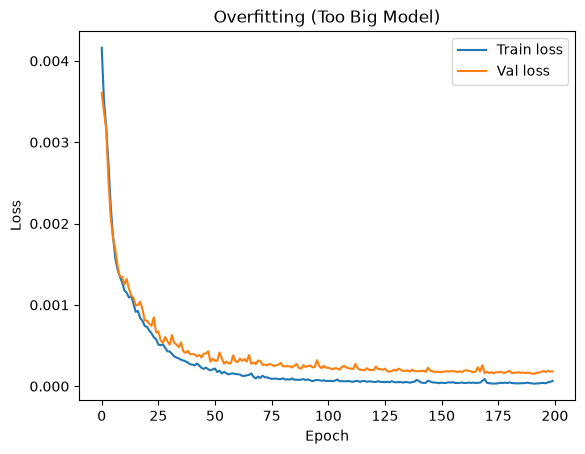

In [32]:
input_dim = x_train_tensor.shape[1] # features
hidden_dim = 256 # hidden units
output_dim = 1 # output units
lr = 0.0001 # Learning rate

train_loader, val_loader = make_loaders(x_train_tensor, y_train_tensor, batch_size=BATCH_SIZE)

big_model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim), 
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, output_dim), 
)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(big_model.parameters(), lr=lr)


train_losses, val_losses = fit_model(big_model, train_loader, val_loader, optimizer, loss_fn, epochs=200)
plot_losses(train_losses, val_losses, title="Overfitting (Too Big Model)")


# Fix overfitting with dropout

Epoch 001 | train=0.0066 | val=0.0022
Epoch 010 | train=0.0041 | val=0.0022
Epoch 020 | train=0.0037 | val=0.0020
Epoch 030 | train=0.0025 | val=0.0012
Epoch 040 | train=0.0022 | val=0.0011
Epoch 050 | train=0.0023 | val=0.0011
Epoch 060 | train=0.0019 | val=0.0010
Epoch 070 | train=0.0021 | val=0.0009
Epoch 080 | train=0.0020 | val=0.0009
Epoch 090 | train=0.0017 | val=0.0008
Epoch 100 | train=0.0015 | val=0.0008
Epoch 110 | train=0.0017 | val=0.0007
Epoch 120 | train=0.0014 | val=0.0007
Epoch 130 | train=0.0014 | val=0.0007
Epoch 140 | train=0.0013 | val=0.0006
Epoch 150 | train=0.0012 | val=0.0005
Epoch 160 | train=0.0011 | val=0.0005
Epoch 170 | train=0.0011 | val=0.0005
Epoch 180 | train=0.0010 | val=0.0004
Epoch 190 | train=0.0009 | val=0.0003
Epoch 200 | train=0.0009 | val=0.0003


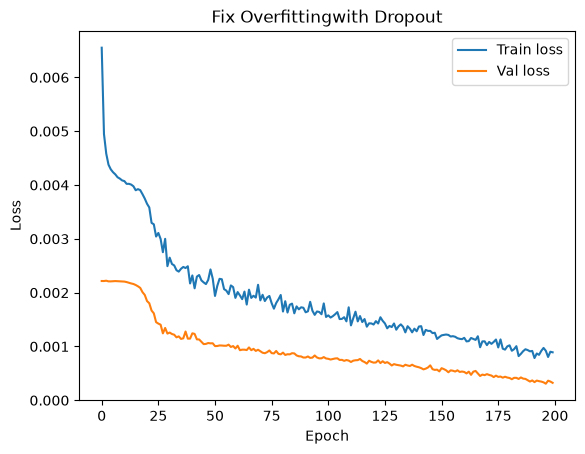

In [34]:
input_dim = x_train_tensor.shape[1] # features
hidden_dim = 256 # hidden units
output_dim = 1 # output units
lr = 0.0001 # Learning rate

train_loader, val_loader = make_loaders(x_train_tensor, y_train_tensor, batch_size=BATCH_SIZE)

big_model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim), 
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(hidden_dim, output_dim), 
)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(big_model.parameters(), lr=lr)


train_losses, val_losses = fit_model(big_model, train_loader, val_loader, optimizer, loss_fn, epochs=200)
plot_losses(train_losses, val_losses, title="Fix Overfittingwith Dropout")


# Dix overfitting with L2 (Weight decay)

Epoch 001 | train=0.0041 | val=0.0039
Epoch 010 | train=0.0025 | val=0.0026
Epoch 020 | train=0.0023 | val=0.0026
Epoch 030 | train=0.0023 | val=0.0025
Epoch 040 | train=0.0023 | val=0.0025
Epoch 050 | train=0.0022 | val=0.0026
Epoch 060 | train=0.0022 | val=0.0024
Epoch 070 | train=0.0023 | val=0.0024
Epoch 080 | train=0.0022 | val=0.0025
Epoch 090 | train=0.0022 | val=0.0025
Epoch 100 | train=0.0022 | val=0.0024


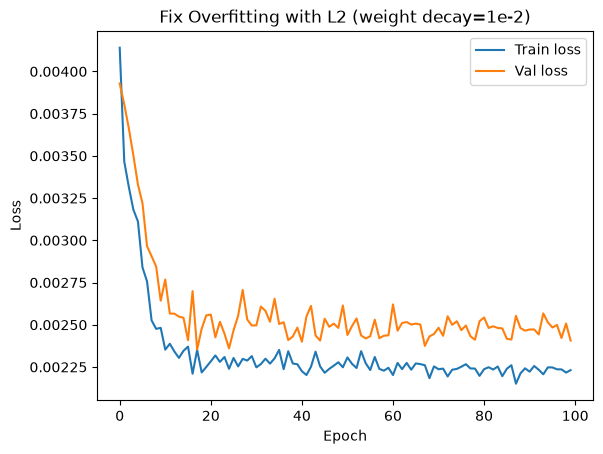

In [39]:
input_dim = x_train_tensor.shape[1] # features
hidden_dim = 256 # hidden units
output_dim = 1 # output units
lr = 0.001 # Learning rate

train_loader, val_loader = make_loaders(x_train_tensor, y_train_tensor, batch_size=BATCH_SIZE)

big_model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim), 
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, output_dim), 
)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(big_model.parameters(), lr=lr, weight_decay=1e-3)


train_losses, val_losses = fit_model(big_model, train_loader, val_loader, optimizer, loss_fn, epochs=100)
plot_losses(train_losses, val_losses, title="Fix Overfitting with L2 (weight decay=1e-2)")


# BatchNorm

Epoch 001 | train=0.0119 | val=0.0034
Epoch 010 | train=0.0017 | val=0.0013
Epoch 020 | train=0.0013 | val=0.0007
Epoch 030 | train=0.0009 | val=0.0006
Epoch 040 | train=0.0007 | val=0.0005
Epoch 050 | train=0.0006 | val=0.0004
Epoch 060 | train=0.0006 | val=0.0003
Epoch 070 | train=0.0004 | val=0.0003
Epoch 080 | train=0.0004 | val=0.0002
Epoch 090 | train=0.0004 | val=0.0002
Epoch 100 | train=0.0003 | val=0.0003


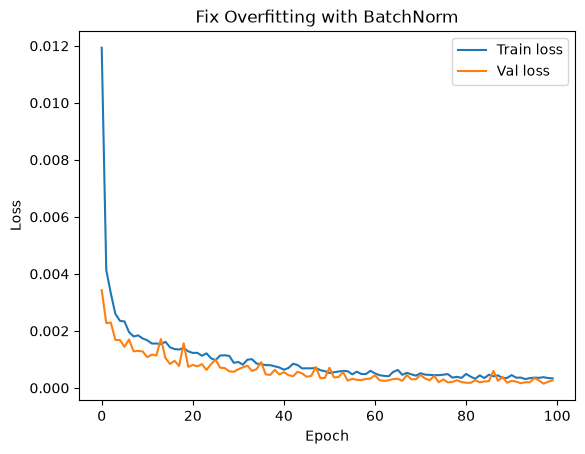

In [43]:
input_dim = x_train_tensor.shape[1] # features
hidden_dim = 128 # hidden units
output_dim = 1 # output units
lr = 0.001 # Learning rate

train_loader, val_loader = make_loaders(x_train_tensor, y_train_tensor, batch_size=BATCH_SIZE)

big_model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim), 
    nn.BatchNorm1d(hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.BatchNorm1d(hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, output_dim), 
)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(big_model.parameters(), lr=lr)


train_losses, val_losses = fit_model(big_model, train_loader, val_loader, optimizer, loss_fn, epochs=100)
plot_losses(train_losses, val_losses, title="Fix Overfitting with BatchNorm")


# Early stopping

Epoch 001 | train=0.0040 | val=0.0019
Epoch 010 | train=0.0009 | val=0.0006
Epoch 020 | train=0.0005 | val=0.0007
Epoch 030 | train=0.0002 | val=0.0005
Epoch 040 | train=0.0001 | val=0.0004
Epoch 050 | train=0.0003 | val=0.0003
Epoch 060 | train=0.0001 | val=0.0004
Early stop at epoch 67 (best val=0.0002)


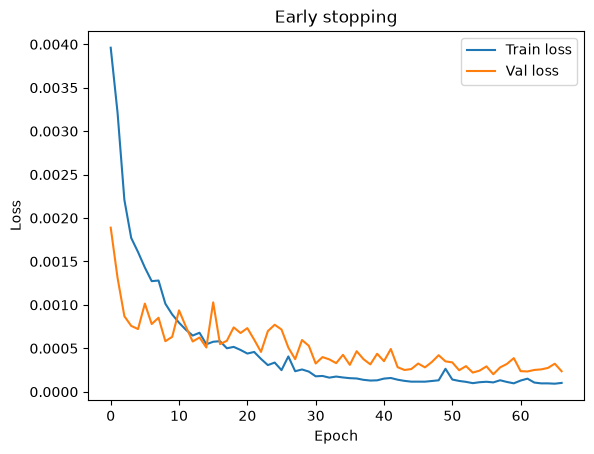

In [44]:
input_dim = x_train_tensor.shape[1] # features
hidden_dim = 128 # hidden units
output_dim = 1 # output units
lr = 0.001 # Learning rate

train_loader, val_loader = make_loaders(x_train_tensor, y_train_tensor, batch_size=BATCH_SIZE)

big_model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim), 
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, output_dim), 
)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(big_model.parameters(), lr=lr)


train_losses, val_losses = fit_model(big_model, train_loader, val_loader, optimizer, loss_fn, epochs=100, early_stop_patience=10)
plot_losses(train_losses, val_losses, title="Early stopping")
